# Importing Required Libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Download Historical Stock Data

In [2]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
data = yf.download(
    tickers,
    start="2022-01-01",
    end="2025-01-01",
    auto_adjust=False,
    group_by="column")

adj_close = data['Adj Close']
returns = adj_close.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


# Define Portfolio Performance Function

In [ ]:
#Esta función calcula el retorno esperado anual y el riesgo (volatilidad) anual de un portafolio, dados sus pesos, los retornos promedio y la matriz de covarianza de los activos.


def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights) * 252

    # Volatilidad (riesgo) anual del portafolio:
    # - wᵀ Σ w = varianza diaria del portafolio
    # - raíz cuadrada para pasar a desviación estándar
    # - se multiplica por √252 para anualizar
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Devuelve:
    # - retorno anual esperado
    # - volatilidad anual del portafolio
    return returns, std_dev


# Define Objective Function (Maximising Sharpe Ratio)

In [ ]:
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.01):
    # Calcula el retorno anual esperado y la volatilidad anual
    # usando la función portfolio_performance
    returns, std_dev = portfolio_performance(weights, mean_returns, cov_matrix)

    # Cálculo del Sharpe Ratio:
    # (retorno del portafolio - tasa libre de riesgo) / volatilidad
    sharpe_ratio = (returns - risk_free_rate) / std_dev

    # Se regresa el Sharpe en negativo porque la mayoría
    # de los optimizadores numéricos MINIMIZAN funciones
    # y aquí queremos MAXIMIZAR el Sharpe
    return -sharpe_ratio


# Run the Optimisation

In [ ]:
# Este bloque resuelve un problema de optimización de portafolios tipo Markowitz, buscando los pesos (sin short selling) que maximizan el Sharpe Ratio bajo la restricción de que el capital total invertido sea 100%.

# Retornos promedio diarios de cada activo
# (una Serie con longitud = número de activos)
mean_returns = returns.mean()

# Matriz de covarianza diaria entre los activos
# Captura cómo se mueven juntos (riesgo conjunto)
cov_matrix = returns.cov()

# Número total de activos en el portafolio
num_assets = len(tickers)

# Restricción de igualdad:
# La suma de los pesos debe ser exactamente 1 (100% del capital invertido)
constraints = {
    'type': 'eq',
    'fun': lambda x: np.sum(x) - 1
}

# Límites para cada peso:
# (0, 1) → no se permite short selling ni apalancamiento
bounds = tuple((0, 1) for _ in range(num_assets))


# Portafolio inicial igualmente ponderado
# Ejemplo: si hay 4 activos → [0.25, 0.25, 0.25, 0.25]
initial_guess = num_assets * [1. / num_assets]

# Se usa SLSQP porque:
# - permite restricciones (constraints)
# - permite límites en variables (bounds)
# - es adecuado para problemas continuos no lineales
optimal = minimize(
    negative_sharpe,          # función objetivo (maximizar Sharpe)
    initial_guess,            # punto inicial
    args=(mean_returns, cov_matrix),  # datos necesarios
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)


# Display Results

In [ ]:
# Este bloque interpreta la solución de la optimización, mostrando cómo se distribuye el capital entre activos y cuál es el retorno esperado, el riesgo y el Sharpe Ratio del portafolio óptimo.

risk_free_rate = 0.01

optimal_weights = optimal.x
expected_return, expected_volatility = portfolio_performance(optimal_weights, mean_returns, cov_matrix)

sharpe = (expected_return - risk_free_rate) / expected_volatility

print("Optimal Weights:", np.round(optimal_weights, 3))
print("Expected Annual Return:", round(expected_return, 3))
print("Annual Volatility:", round(expected_volatility, 3))
print("Sharpe Ratio:", round(sharpe, 3))

Optimal Weights: [0.703 0.117 0.143 0.024 0.014]
Expected Annual Return: 0.149
Annual Volatility: 0.262
Sharpe Ratio: 0.531


# Visualising portfolio Allocation

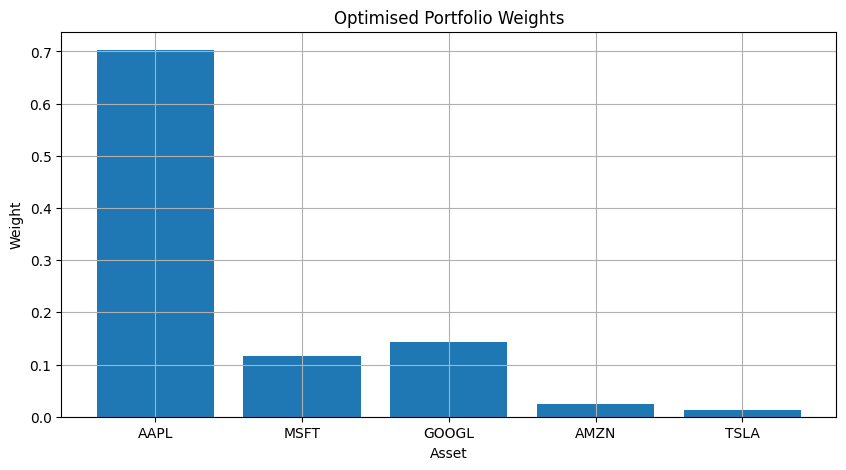

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(tickers, optimal_weights)
plt.title("Optimised Portfolio Weights")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.grid(True)
plt.show()